# Norms, Descriptives & Inter-Individual Differences
Covers RQ2: OCEAN score distributions, normality tests, human BFI benchmarking,
social desirability correlations, and refusal/completion rates.

In [1]:
### 0) IMPORTS
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import zscore, kstest

from src.reading_data import create_final_dfs
from src.visualizations import (
    apply_paper_style,
    OCEAN_COLS,
    IMPACT_SIX,
    HUMAN_BFI_NORMS,
    descriptive_stats,
    ks_normality_tests,
    plot_ocean_distributions,
    plot_trait_correlation_heatmap,
    plot_trait_covariances
)

os.makedirs("../../doc/figs", exist_ok=True)
apply_paper_style()

In [2]:
### 1) LOAD DATA
df_all, df_A, df_B, df_cfa, df_soc_des, df_metadata, df_lmm, df_lmm_key = create_final_dfs()

/Users/kimzierahn/PycharmProjects/BigFive-LLM-Evaluation/src/reading_data.py:437: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(df_lmm["Release_date"], errors="coerce")



Created dataframes:
df_all:      (143950, 16)
df_A:        (14396, 18)
df_B:        (244, 7)
df_cfa:      (244, 44)
df_cfa_soc_des: (244, 59)
df_metadata: (244, 20)
df_lmm:      (106058, 11)
df_lmm_key:      (106058, 13)


In [3]:
meta = pd.read_csv("../../dat/03_large_scale_administration/meta_info_models.csv")

In [4]:
models_only_in_meta = set(meta["Model_ID"]) - set(df_B["model"])
models_only_in_df_B = set(df_B["model"]) - set(meta["Model_ID"])

print("In meta but not df_B:")
print(models_only_in_meta)

print("\nIn df_B but not meta:")
print(models_only_in_df_B)

In meta but not df_B:
set()

In df_B but not meta:
set()


## 1.1 Descriptive Statistics

In [5]:
### 2) DESCRIPTIVE STATISTICS
# Mean, SD, min, max across all models for each OCEAN trait + social desirability
desc_cols = OCEAN_COLS + ["social-desirability"]
desc_stats = descriptive_stats(df_B, cols=desc_cols)

n_models = df_metadata["model"].nunique()

families = (
    df_metadata["Family"]
    .dropna()
    .astype(str)
    .str.lower()
    .nunique()
)

families_vals = (
    df_metadata["Family"]
    .dropna()
    .astype(str)
    .str.lower()
    .unique()
)

regions = (
    df_metadata["Region"]
    .dropna()
    .value_counts()
)

licenses = (
    df_metadata["license_group"]
    .value_counts(dropna=False)
)

reasoning_counts = (
    df_metadata["Reasoning"]
    .astype(str)
    .str.lower()
    .value_counts()
)

release_dates = pd.to_datetime(
    df_metadata["Release_date"],
    errors="coerce"
)

min_release = release_dates.min()
max_release = release_dates.max()

params = pd.to_numeric(
    df_metadata["params_numeric"],
    errors="coerce"
)

min_params = params.min()
max_params = params.max()

df_all_OCEAN = df_all[df_all["dimension"].isin(OCEAN_COLS)]

valid_mask = pd.to_numeric(
    df_all["response"],
    errors="coerce"
).isin([1, 2, 3, 4, 5])

valid_mask_OCEAN = pd.to_numeric(
    df_all_OCEAN["response"],
    errors="coerce"
).isin([1, 2, 3, 4, 5])

total_rows = len(df_all)
total_rows_OCEAN = len(df_all_OCEAN)

n_valid = valid_mask.sum()
n_invalid = (~valid_mask).sum()
n_valid_OCEAN = valid_mask_OCEAN.sum()
n_invalid_OCEAN = (~valid_mask_OCEAN).sum()

completion_rate = n_valid / total_rows * 100
refusal_rate = n_invalid / total_rows * 100
completion_rate_OCEAN = n_valid_OCEAN / total_rows_OCEAN * 100
refusal_rate_OCEAN = n_invalid_OCEAN / total_rows_OCEAN * 100

model_refusal = (
    df_all_OCEAN.assign(
        valid=pd.to_numeric(
            df_all_OCEAN["response"],
            errors="coerce"
        ).isin([1, 2, 3, 4, 5])
    )
    .groupby("model")
    .agg(
        total=("valid", "size"),
        valid=("valid", "sum")
    )
)

model_refusal["refusal_rate"] = (
    1 - (model_refusal["valid"] / model_refusal["total"])
) * 100

dispersion = (
    df_B[OCEAN_COLS]
    .agg(["mean", "std", "min", "max"])
    .T
    .round(3)
)

country_family = (
    df_metadata[["Region", "Family"]]
    .dropna()
    .drop_duplicates()
    .groupby("Region")["Family"]
    .apply(lambda x: sorted(x.astype(str).unique()))
)

/var/folders/tq/zy_cnh614c5d9k3yfc0_sfdr0000gn/T/ipykernel_3732/3750315967.py:42: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  release_dates = pd.to_datetime(


In [6]:
print("=== Descriptive Statistics ===")

print(f"N models: {n_models}")
print(f"N model families: {families}")
print(f"Families: {families_vals}")

print("\nRegions:")
print(regions.to_string())

for country, fams in country_family.items():
    print(f"\n{country}:")
    for f in fams:
        print(f"  - {f}")

print("\nLicense groups:")
print(licenses.to_string())

print("\nReasoning models:")
print(reasoning_counts.to_string())

print("\nRelease date range:")
print(f"{min_release.date()} to {max_release.date()}")

print("\nParameter scale:")
print(f"{min_params:.2f}B to {max_params:.2f}B")

print("\n\n=====\n\n")

print(f"Total responses (incl. SD): {total_rows:,}")
print(f"Valid responses (incl. SD): {n_valid:,}")
print(f"Invalid / refusal responses (incl. SD): {n_invalid:,}")

print(f"Total responses (OCEAN): {total_rows_OCEAN:,}")
print(f"Valid responses (OCEAN): {n_valid_OCEAN:,}")
print(f"Invalid / refusal responses (OCEAN): {n_invalid_OCEAN:,}")

print(f"\nCompletion rate (OCEAN): {completion_rate_OCEAN:.2f}%")
print(f"Refusal rate (OCEAN): {refusal_rate_OCEAN:.2f}%")

print("\n\n=====\n\n")

print(
    model_refusal["refusal_rate"]
    .describe()
    .round(2)
    .to_string()
)

print("\nTop 20 highest refusal rates:")
print(
    model_refusal["refusal_rate"]
    .sort_values(ascending=False)
    .head(20)
    .round(2)
    .to_string()
)

=== Descriptive Statistics ===
N models: 244
N model families: 49
Families: <StringArray>
[      'qwen',     'claude',       'seed',   'mythomax',    'minimax',
     'hermes',         'l3',       'mimo',   'deepseek',     'gemini',
      'gemma',      'llama',        'phi',    'mistral',       'kimi',
   'nemotron',    'gpt-oss',       'step',        'glm',        'gpt',
    'granite',   'o-series',       'aion',       'nova',    'trinity',
      'ernie',    'ui tars',    'command',     'cogito',        'rnj',
    'mercury',       'ling',        'kat',        'lfm',     'weaver',
      'morph',        'owl',      'sonar',  'intellect',       'reka',
     'relace',     'router',    'hunyuan',        'hy3',   'rocinate',
 'unslopnemo',       'remm',     'falcon',       'grok']
Length: 49, dtype: str

Regions:
Region
US       112
china     98
EU        21
other      9
uae        4

EU:
  - mistral

US:
  - claude
  - cogito
  - gemini
  - gemma
  - gpt
  - gpt-oss
  - granite
  - grok
  -

In [7]:
print(desc_stats.round(2).to_string())

                     Mean    SD   Min    Q1  Median    Q3   Max
dimension                                                      
Agreeableness        4.01  0.54  2.66  3.59    4.25  4.42  4.74
Conscientiousness    4.05  0.59  2.67  3.64    4.26  4.55  4.99
Extraversion         3.65  0.47  2.45  3.36    3.68  3.98  4.95
Neuroticism          2.06  0.57  1.09  1.61    1.94  2.51  3.76
Openness             3.72  0.61  1.80  3.37    3.84  4.11  4.76
social-desirability  3.75  0.56  1.80  3.46    3.88  4.11  4.65


## 1.2 Normality Tests (Kolmogorov–Smirnov)

In [8]:
### 3) KS NORMALITY TESTS
ks_results = ks_normality_tests(df_metadata, cols=OCEAN_COLS)

print("=== Kolmogorov–Smirnov Normality Tests ===")
print(ks_results.to_string(index=False))

=== Kolmogorov–Smirnov Normality Tests ===
            trait     D     p interpretation
    Agreeableness 0.187 0.000     non-normal
Conscientiousness 0.143 0.000     non-normal
     Extraversion 0.044 0.707 approx. normal
      Neuroticism 0.108 0.006     non-normal
         Openness 0.115 0.003     non-normal


## 1.3 OCEAN Score Distributions — All Models
Boxplot (with human BFI baseline), histogram + KDE, and QQ-plot per trait.

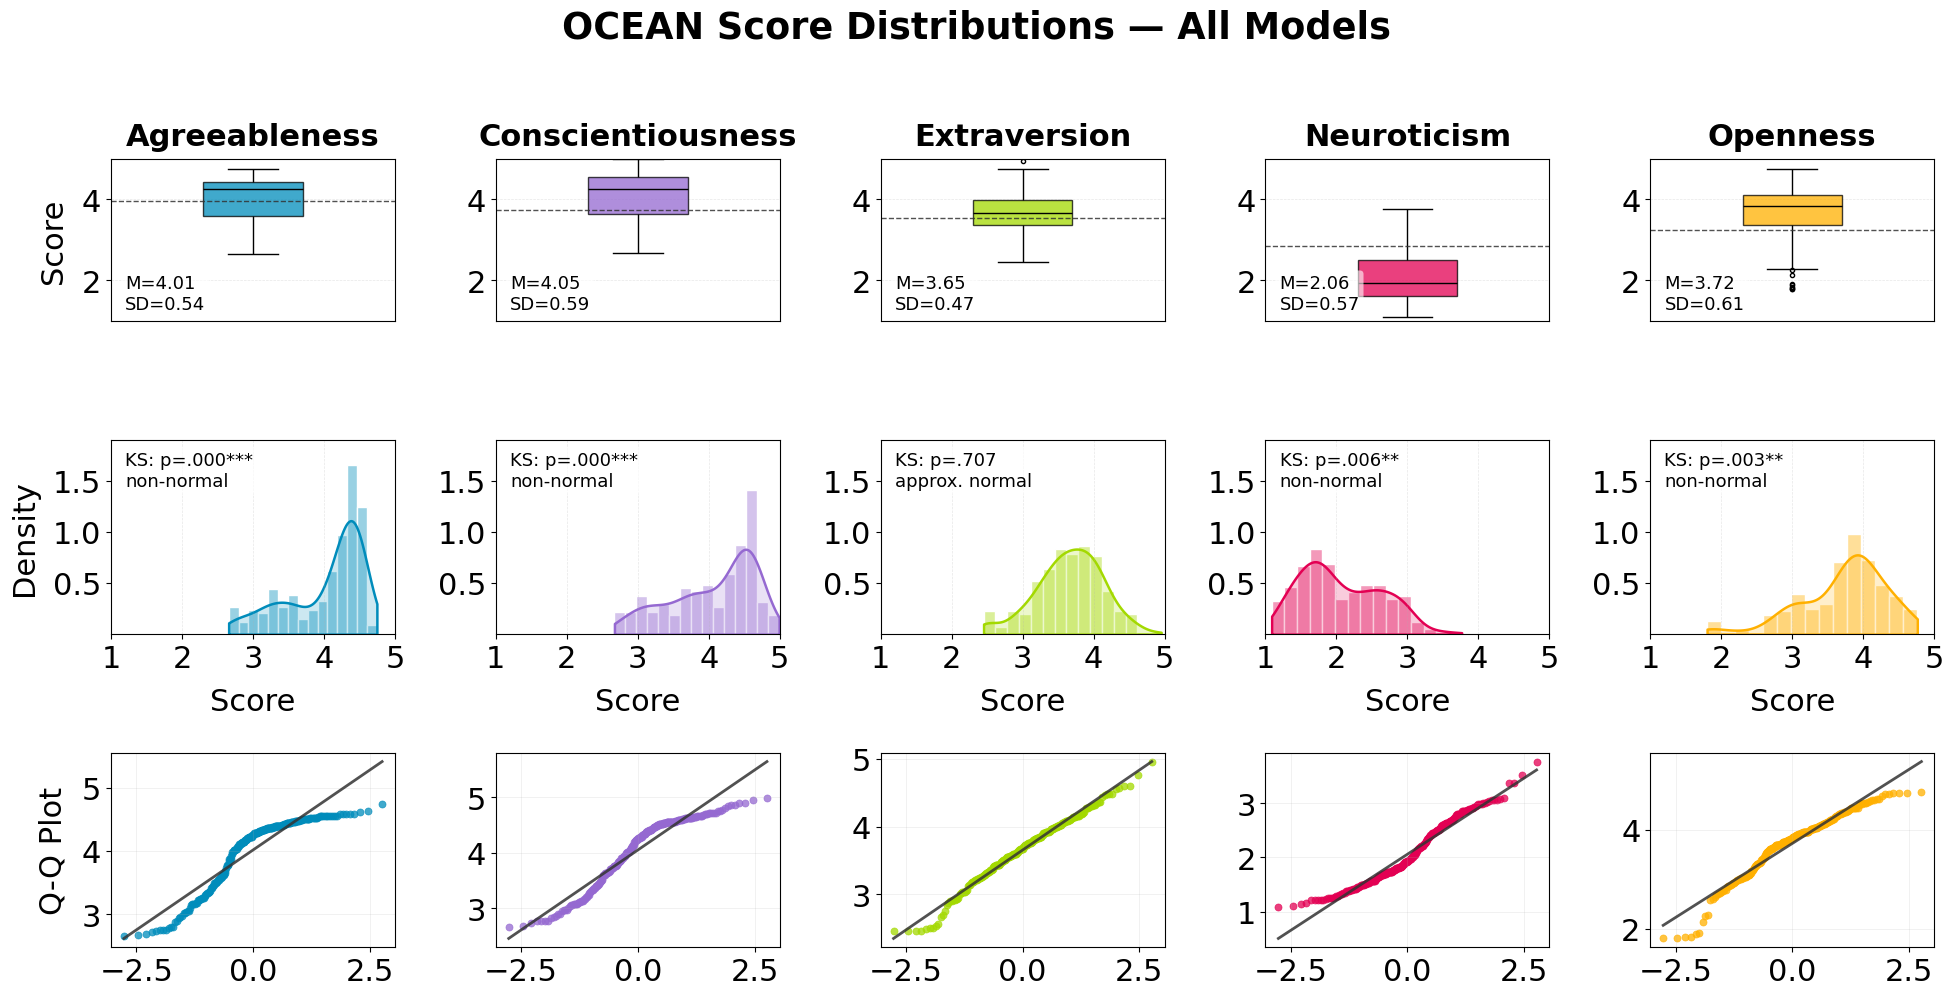

In [9]:
### 4) DISTRIBUTION FIGURE (RQ2)
fig = plot_ocean_distributions(
    df_metadata,
    cols=OCEAN_COLS,
    title="OCEAN Score Distributions — All Models",
    save_path="../../doc/figs/fig_ocean_all_models.pdf",
)
plt.show()

## 1.4 Social Desirability Correlations

In [10]:
### 5) PEARSON CORRELATIONS WITH SOCIAL DESIRABILITY
sd_col = "social-desirability"

sd_corrs = []
for trait in OCEAN_COLS:
    tmp = df_B[[trait, sd_col]].dropna()
    r   = tmp[trait].corr(tmp[sd_col], method="pearson")
    sd_corrs.append({"Trait": trait, "r_with_SD": r})

df_sd_corr = pd.DataFrame(sd_corrs)
print("=== Pearson Correlations with Social Desirability ===")
print(df_sd_corr.round(3).to_string(index=False))

=== Pearson Correlations with Social Desirability ===
            Trait  r_with_SD
    Agreeableness      0.772
Conscientiousness      0.740
     Extraversion      0.736
      Neuroticism     -0.526
         Openness      0.723


## 1.5 Trait Correlations (from 5-factor solution CFA)

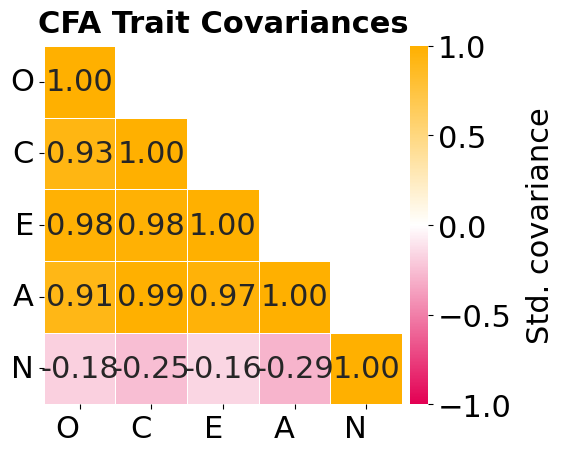

In [11]:
### 6) COVARIANCES HEATMAP FROM CFA
cov_vals = {
    ("Extraversion", "Agreeableness"): 0.966,
    ("Extraversion", "Conscientiousness"): 0.978,
    ("Extraversion", "Neuroticism"): -0.160,
    ("Extraversion", "Openness"): 0.981,

    ("Agreeableness", "Conscientiousness"): 0.993,
    ("Agreeableness", "Neuroticism"): -0.293,
    ("Agreeableness", "Openness"): 0.913,

    ("Conscientiousness", "Neuroticism"): -0.251,
    ("Conscientiousness", "Openness"): 0.927,

    ("Neuroticism", "Openness"): -0.185,
}

fig = plot_trait_covariances(
    cov_vals,
    title="CFA Trait Covariances",
    save_path="../../doc/figs/fig_covariance_heatmap.pdf"
)

In [12]:
# 7) HUMAN DISTRIBUTION
df = pd.read_csv("../../dat/03_large_scale_administration/BFI228.csv")
item_cols = df.columns

df_items = df[item_cols].copy()
r_cols = [c for c in df_items.columns if c.endswith('R')]
df_items[r_cols] = 6 - df_items[r_cols]

trait_map = {
    'Extraversion': ['talkative', 'researvedR', 'fullenergy', 'enthusiastic', 'quietR',
          'assertive', 'shyR', 'outgoing'],
    'Agreeableness': ['findfaultR', 'helpful', 'quarrelsR', 'forgiving', 'trusting',
          'coldR', 'considerate', 'rudeR', 'cooperative'],
    'Conscientiousness': ['thorough', 'carelessR', 'reliable', 'disorganizedR', 'lazyR',
          'persevere', 'efficient', 'plans', 'distractedR'],
    'Neuroticism': ['blue', 'relaxedR', 'tense', 'worries', 'emostableR',
          'moody', 'calmR', 'nervous'],
    'Openness': ['ideas', 'curious', 'ingenious', 'imagination', 'inventive',
          'artistic', 'routineR', 'reflect', 'nonartisticR', 'sophisticated']
}

scores = pd.DataFrame({
    trait: df_items[cols].mean(axis=1) for trait, cols in trait_map.items()
})

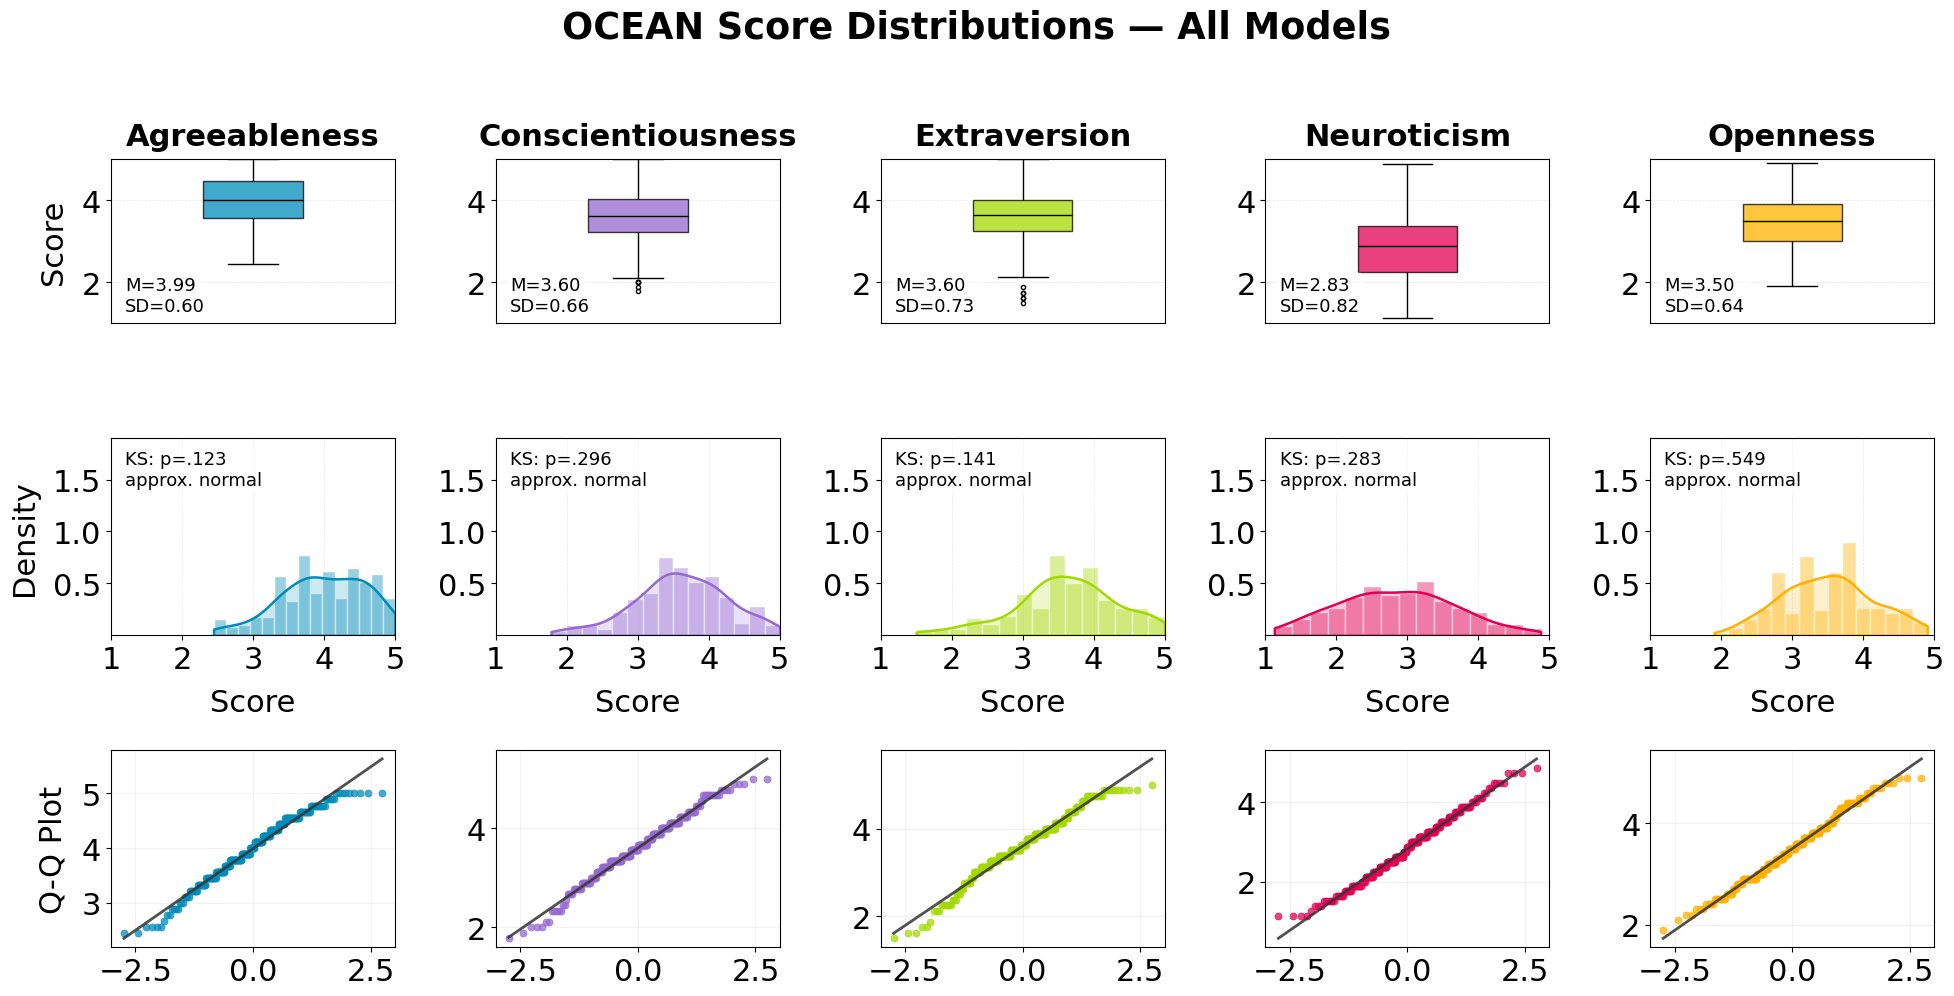

In [13]:
fig = plot_ocean_distributions(
    scores,
    cols=OCEAN_COLS,
    title="OCEAN Score Distributions — All Models",
    save_path="../../doc/figs/fig_ocean_all_models_HUMAN.pdf",
    show_mean=False
)
plt.show()